# Notebook 3 : Exploratory Data Analysis
### Nutrition Intelligence System | Predicting Protein, Fat, and Sugar in Foods

## 0. Imports & loading

In this part, we begin by importing the required libraries, then specifying the file paths and loading the CSV files

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
import numpy as np
# File paths in  drive
file_path1 = '/content/drive/MyDrive/nutri_project/data/corrupted_food_dataset.csv'
file_path2 = '/content/drive/MyDrive/nutri_project/data/original_food_dataset.csv'

# Load svs for each file
original_food_dataset = pd.read_csv(file_path2)
corrupted_food_dataset = pd.read_csv(file_path1)

Mounted at /content/drive


#EDA

In this section, we perform Exploratory Data Analysis (EDA) on both datasets before encoding. The first objective is to verify data quality and confirm that preprocessing was applied correctly.The second objective is to discover relationships and correlations between features and targets, which will guide our model selection.

###1.EDA for original data
The original data is the data after pivoting and merge it contains nutrients ,category without encoding and food id (no null values were found)

In [ ]:
print("=" * 70)
print("MISSING VALUES")
print("=" * 70)
print(original_food_dataset.isnull().sum().sum())

MISSING VALUES
0


In [ ]:

targets = ['Protein', 'Total lipid (fat)', 'Sugars, Total']
feature_cols = [col for col in original_food_dataset.columns
                if col not in targets + ['fdc_id', 'description', 'food_category_id']]

print("=" * 70)
print("DATASET: USDA SR LEGACY — CLEAN DATA")
print("=" * 70)
print(f"Shape: {original_food_dataset.shape}")
print(f"Number of features: {len(feature_cols)}")
print(f"Number of targets: {len(targets)}")

DATASET: USDA SR LEGACY — CLEAN DATA
Shape: (7793, 51)
Number of features: 46
Number of targets: 3


In [ ]:
# Statistiques descriptives
print("\n" + "=" * 70)
print("STATISTIQUES DESCRIPTIVES")
print("=" * 70)
print(original_food_dataset.describe().T)


STATISTIQUES DESCRIPTIVES
                                 count           mean          std       min  \
fdc_id                          7793.0  171408.000000  2249.789657  167512.0   
Protein                         7793.0      11.926873    10.859968       0.0   
Total lipid (fat)               7793.0      10.687361    16.381682       0.0   
Carbohydrate, by difference     7793.0      19.569788    25.705634       0.0   
Ash                             7793.0       1.736850     3.067944       0.0   
Starch                          7793.0       2.533526     9.439792       0.0   
Alcohol, ethyl                  7793.0       0.127679     1.643964       0.0   
Water                           7793.0      56.033466    29.491176       0.0   
Caffeine                        7793.0       2.915565    87.125310       0.0   
Theobromine                     7793.0       4.939433    61.418898       0.0   
Fiber, total dietary            7793.0       1.836392     4.183677       0.0   
Calcium, Ca  

####Interpretation:

This table shows 7,793 food items, The mean is higher than the median for the target variables indicating that the data is not symmetric. Which means that we have variety of foods, where most nutrients appear in low to moderate amounts, while some foods contain much higher values.For Sugar, the median is 0, which means that most foods contain little to no sugar. Also, some features show extreme values because of different measurement units which indicates the need to apply StandardScaler to scale the data before model training

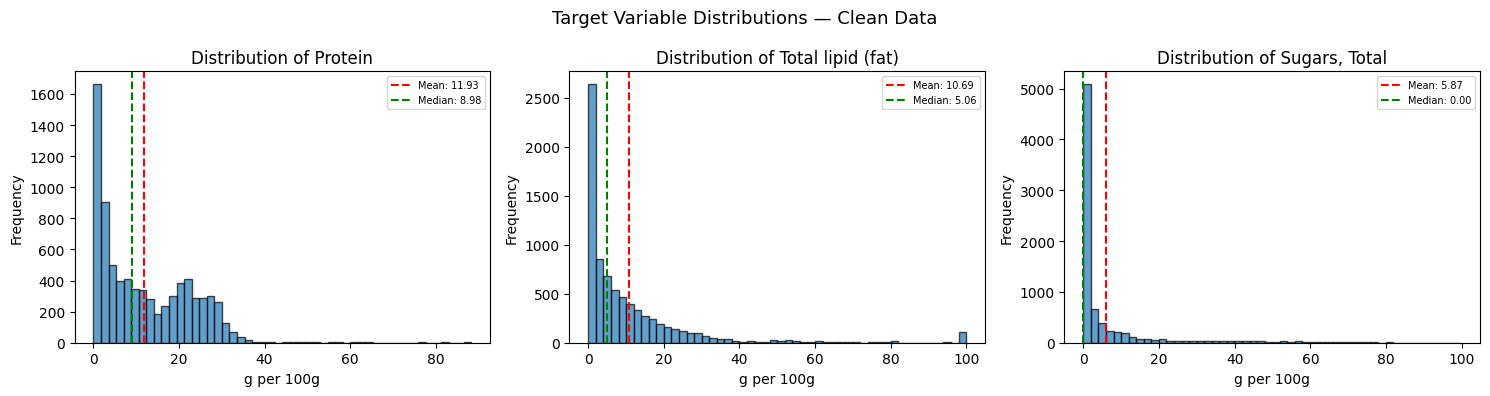

In [ ]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(targets):
  # Distribution du target
    axes[i].hist(original_food_dataset[col], bins=50, edgecolor='black', alpha=0.7)
    axes[i].axvline(original_food_dataset[col].mean(), color='red',
                    linestyle='--', label=f'Mean: {original_food_dataset[col].mean():.2f}')
    axes[i].axvline(original_food_dataset[col].median(), color='green',
                    linestyle='--', label=f'Median: {original_food_dataset[col].median():.2f}')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel('g per 100g')
    axes[i].set_ylabel('Frequency')
    axes[i].legend(fontsize=7)

plt.suptitle('Target Variable Distributions — Clean Data', fontsize=13)
plt.tight_layout()
plt.show()

These histograms confirms what we observed in the previous table

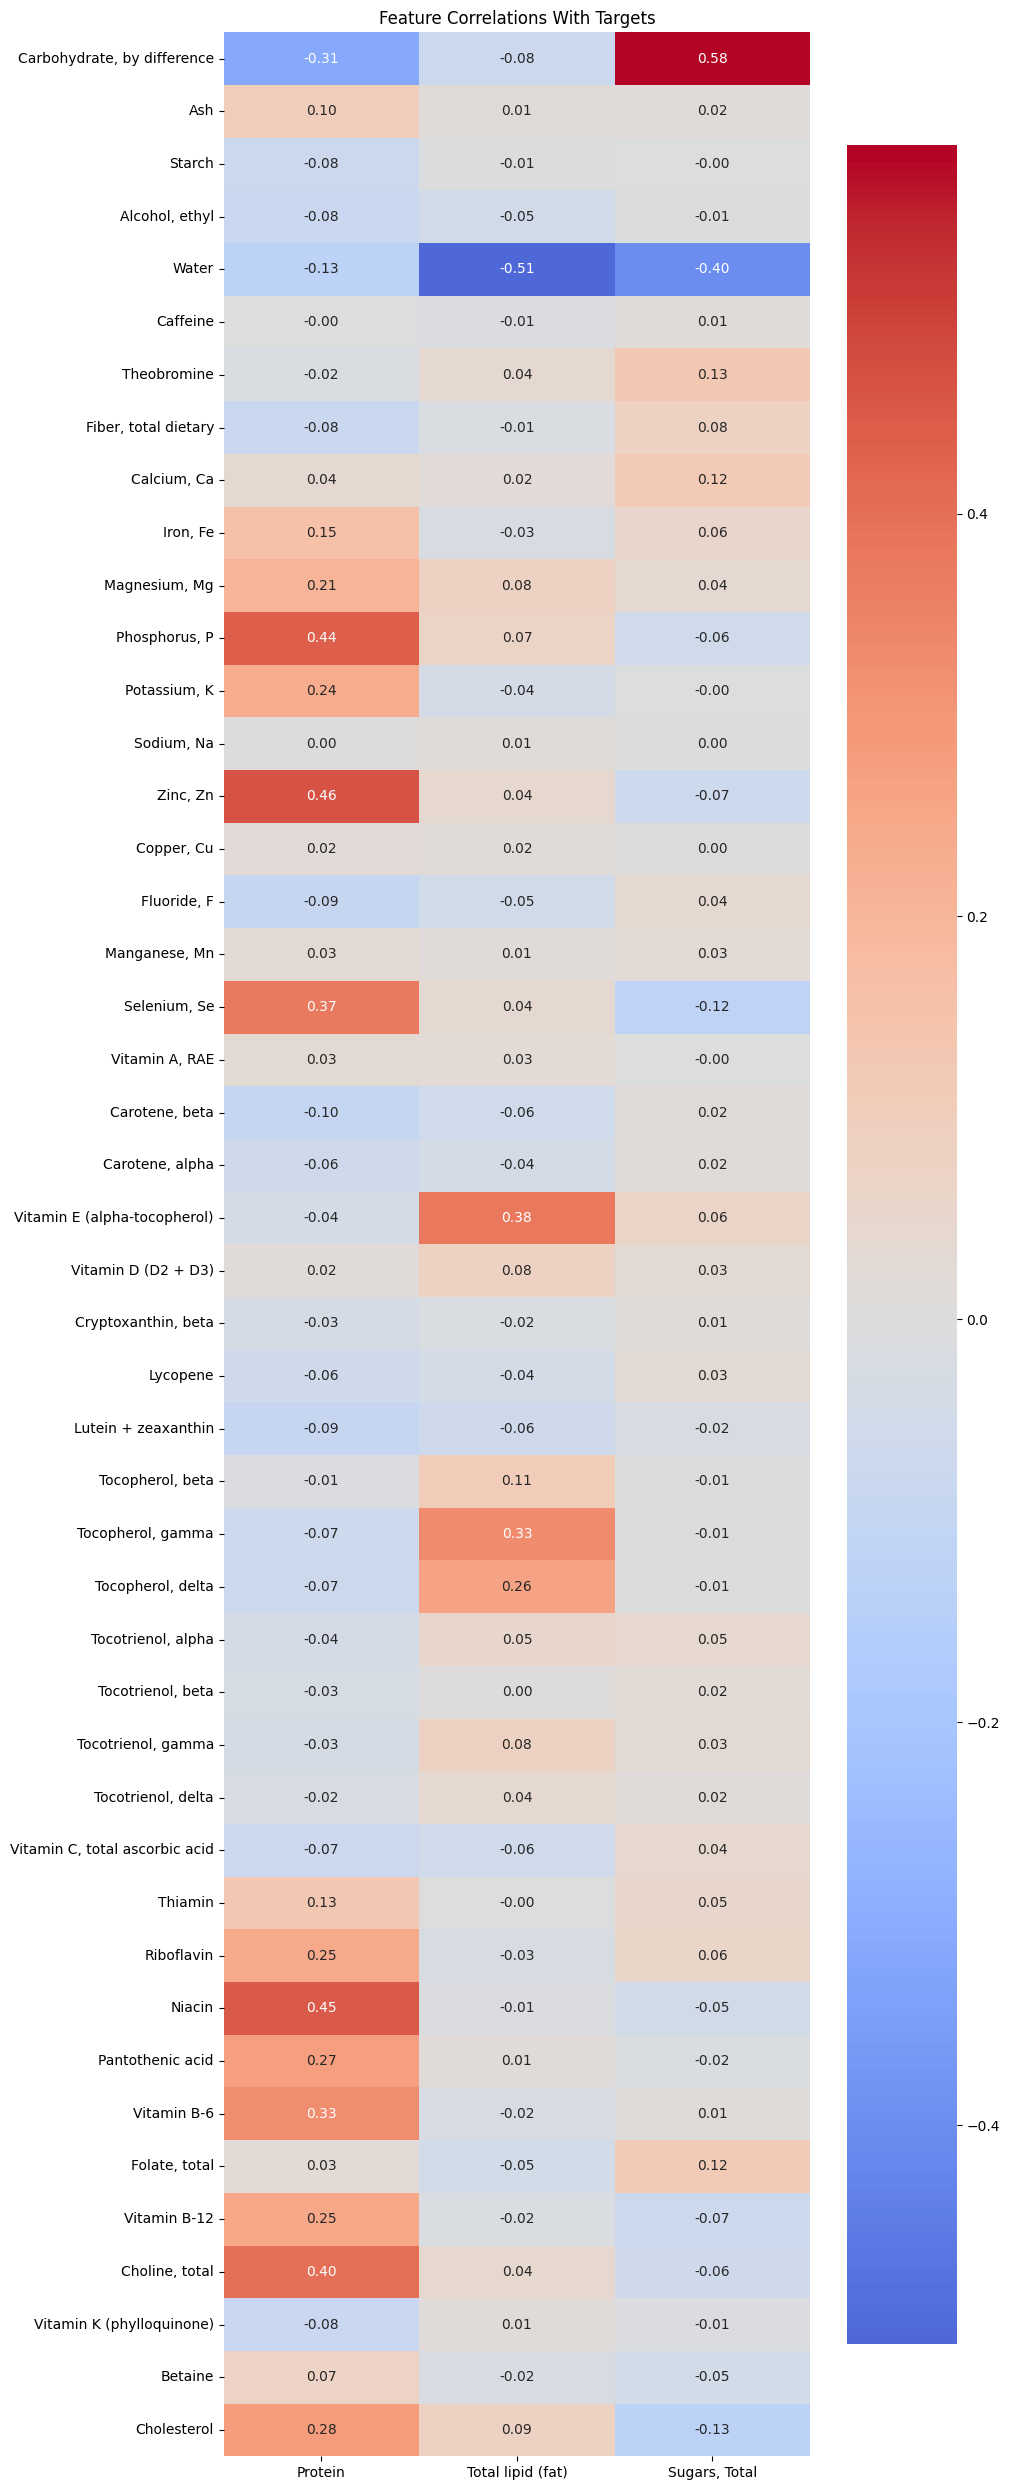

In [ ]:
import seaborn as sns
corr_matrix = original_food_dataset[feature_cols + targets].corr()
target_corr = corr_matrix[targets].drop(index=targets)

plt.figure(figsize=(10, 25))
sns.heatmap(target_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlations With Targets')
plt.tight_layout()
plt.show()

####Interpretation:
The heatmap shows correlations between nutrients and targets.Some features show moderate positive like protein and zinc or negative relationships like water and fat ,but most correlations are weak to moderate, which means we needmore features
for accurate prediction.

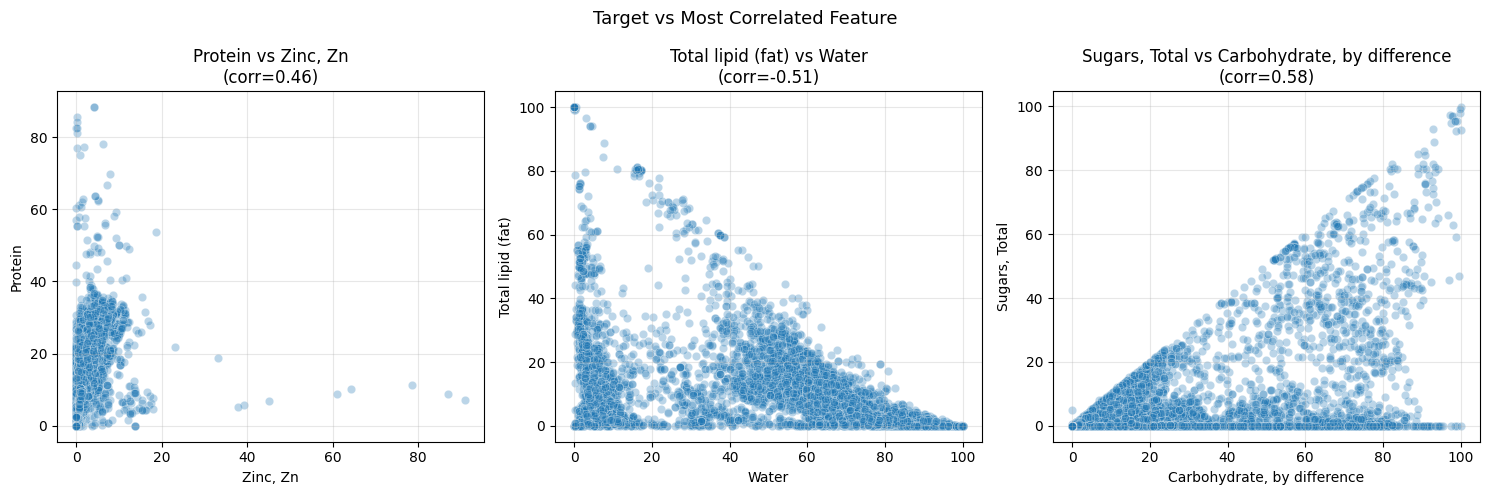

In [ ]:

numeric_cols = original_food_dataset.select_dtypes(include='number').columns.tolist()
corr_matrix = original_food_dataset[numeric_cols].corr()

feature_cols_corr = [col for col in numeric_cols if col not in targets + ['fdc_id']]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, target in enumerate(targets):
    corr_with_target = corr_matrix[target].drop(targets, errors='ignore').abs().sort_values(ascending=False)
    corr_with_target = corr_with_target.drop('fdc_id', errors='ignore')
    best_feature = corr_with_target.index[0]
    corr_val = corr_matrix.loc[best_feature, target]

    sns.scatterplot(data=original_food_dataset, x=best_feature, y=target, alpha=0.3, ax=axes[i])
    axes[i].set_xlabel(best_feature)
    axes[i].set_ylabel(target)
    axes[i].set_title(f'{target} vs {best_feature}\n(corr={corr_val:.2f})')
    axes[i].grid(alpha=0.3)

plt.suptitle('Target vs Most Correlated Feature', fontsize=13)
plt.tight_layout()
plt.show()

**Plot1:** When Zinc increases Protein tends to increase,For protein above 40 we notice zinc is present but in low quantity which means zinc alone is not enough to predict protein.

**Plot 2:** The higher the fat the lower the water

**Plot 3:**
When Carbohydrates increase Sugar tends to increase but high Carbohydrates does not necessarily mean high sugar. Since this is the highest correlation for sugar it shows that sugar is the hardest target to predict among the three.



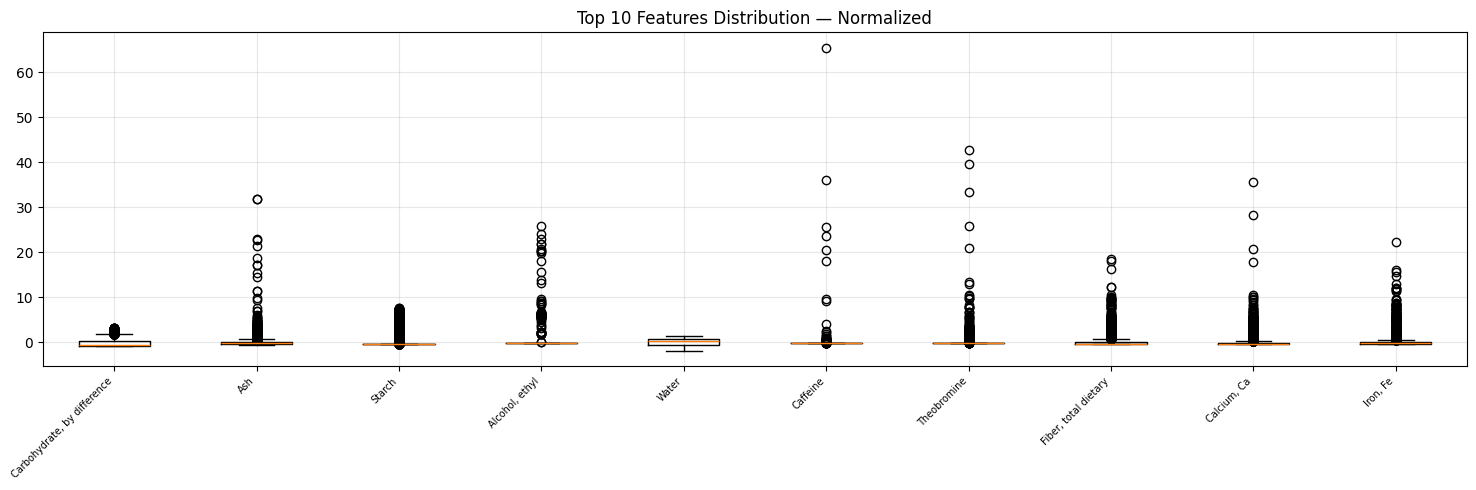

In [ ]:

for i, col in enumerate(targets):
    df_normalized = (original_food_dataset[feature_cols] - original_food_dataset[feature_cols].mean()) / original_food_dataset[feature_cols].std()

plt.figure(figsize=(15, 5))
plt.boxplot([df_normalized[f] for f in feature_cols[:10]])
plt.xticks(range(1, 11), feature_cols[:10], rotation=45, ha='right', fontsize=7)
plt.title('Top 10 Features Distribution — Normalized')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The boxes represent 50% of foods and are all compressed near zero, which means most foods have very low values for these features. The dots above represent extreme outliers This confirms the need for StandardScaler before model training

###2.EDA for Corrupted data
The corrupted data is the original data ,corrupted withnull values ,duplicates outliers ,category without encoding and food id (no null values were found)

In [ ]:
targets = ['Protein', 'Total lipid (fat)', 'Sugars, Total']
feature_cols = [col for col in corrupted_food_dataset.columns
                if col not in targets + ['fdc_id', 'description', 'food_category_id']]

print("=" * 70)
print("DATASET: Corrupted data")
print("=" * 70)
print(f"Shape: {corrupted_food_dataset.shape}")
print(f"Number of features: {len(feature_cols)}")
print(f"Number of targets: {len(targets)}")


DATASET: Corrupted data
Shape: (6876, 51)
Number of features: 46
Number of targets: 3


In [ ]:
# Statistiques descriptives
print("\n" + "=" * 70)
print("STATISTIQUES DESCRIPTIVES")
print("=" * 70)
print(corrupted_food_dataset.describe().T)


STATISTIQUES DESCRIPTIVES
                                 count           mean          std       min  \
fdc_id                          6876.0  171422.850058  2238.299247  167513.0   
Protein                         6876.0      12.384795    10.086970       0.0   
Total lipid (fat)               6876.0       8.378167    10.779313       0.0   
Carbohydrate, by difference     6876.0      14.957179    21.419874       0.0   
Ash                             6876.0       1.673290     2.990810       0.0   
Starch                          6876.0       2.446139     9.380980       0.0   
Alcohol, ethyl                  6876.0       0.114820     1.522461       0.0   
Water                           6876.0      61.554882    25.180557       0.0   
Caffeine                        6876.0       2.477749    88.965459       0.0   
Theobromine                     6876.0       1.947062    48.089509       0.0   
Fiber, total dietary            6876.0       1.658028     4.195475       0.0   
Calcium, Ca  

The corrupted dataset shows lower means for most nutrients due to missing values pulling distributions down, and lower maximum values for target variables confirming that the added outliers were successfully removed during cleaning

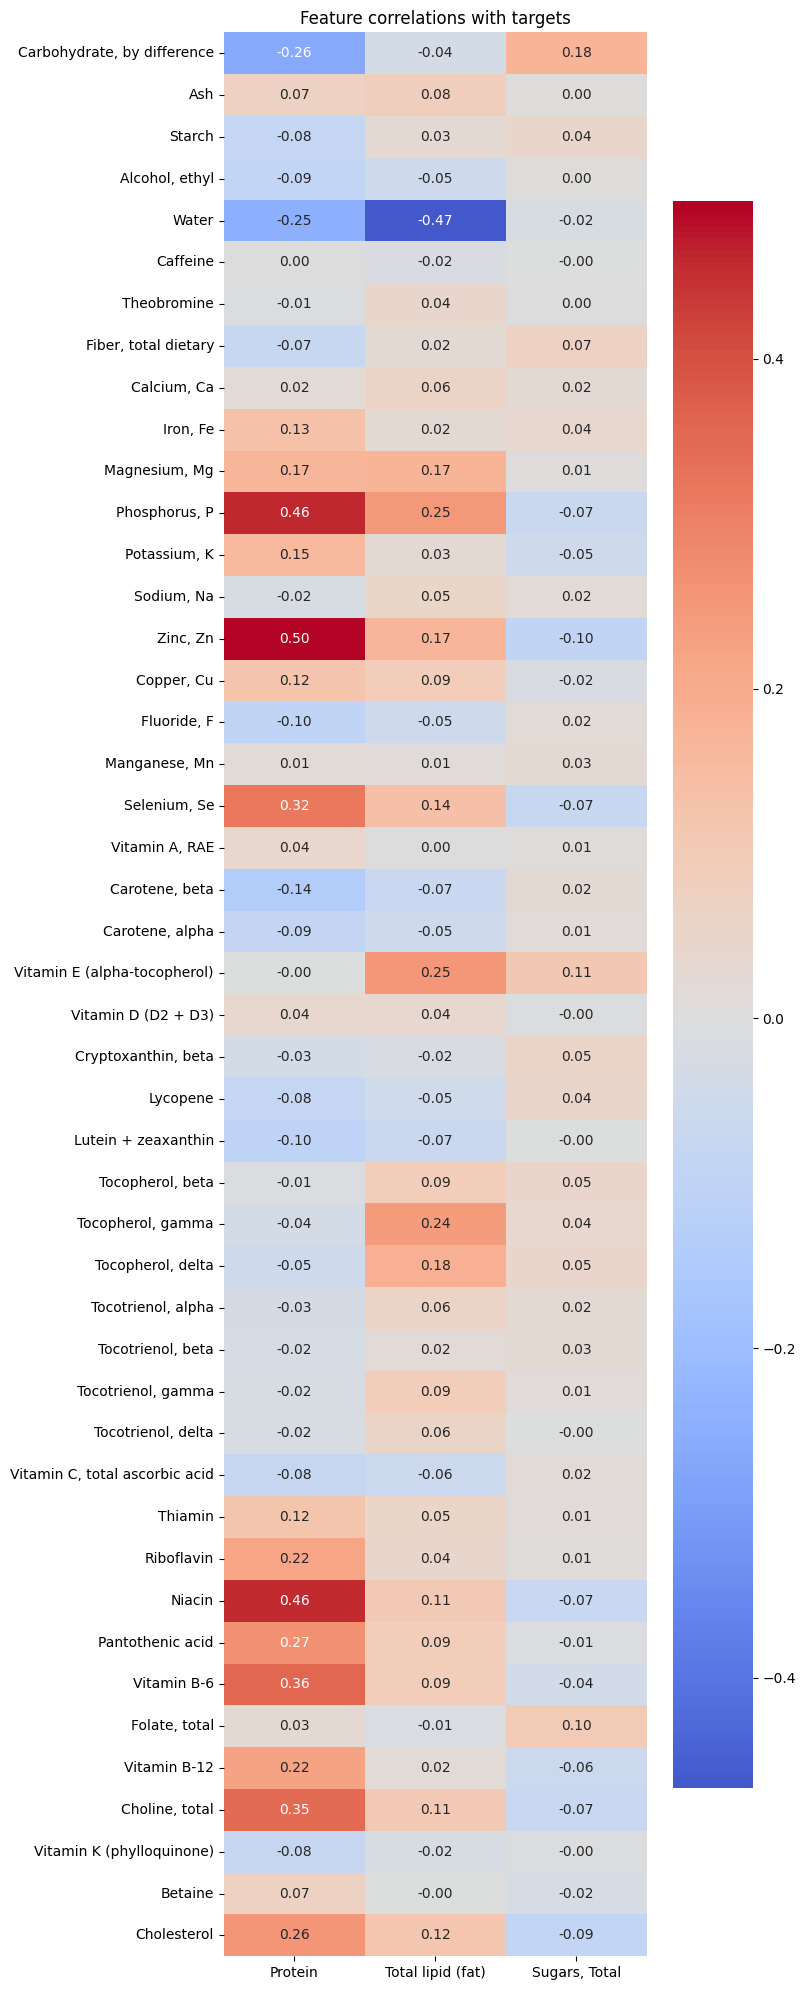

In [ ]:
nutrient_cols= [col for col in feature_cols if col not in targets]

corr_matrix = corrupted_food_dataset[feature_cols + targets].corr()
target_corr = corr_matrix[targets].drop(index=targets)

plt.figure(figsize=(8, 20))
sns.heatmap(target_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature correlations with targets')
plt.tight_layout()
plt.show()

###Interpretation
Comparison of correlation heatmaps between the clean and corrupted cleaned datasets reveals that most feature target relationships were the same or very close after cleaning. However some correlations show notable differences

In [ ]:
from sklearn.feature_selection import f_regression

feature_cols = [col for col in nutrient_cols if col not in targets]
X = corrupted_food_dataset[feature_cols]
results = {}

for target in targets:
    y = corrupted_food_dataset[target]
    f_scores, p_values = f_regression(X, y)

    result_df = pd.DataFrame({
        'feature': feature_cols,
        'f_score': f_scores,
        'p_value': p_values
    }).sort_values('f_score', ascending=False)

    results[target] = result_df
    print(f"\n=== Top 15 features for {target} ===")
    print(result_df.head(15).to_string(index=False))


=== Top 15 features for Protein ===
                    feature     f_score       p_value
                   Zinc, Zn 2242.455761  0.000000e+00
              Phosphorus, P 1847.929603  0.000000e+00
                     Niacin 1798.786703  0.000000e+00
                Vitamin B-6 1003.995818 8.678772e-206
             Choline, total  951.877514 7.184682e-196
               Selenium, Se  799.240137 1.954227e-166
           Pantothenic acid  529.161831 7.202775e-113
Carbohydrate, by difference  514.638531 6.226517e-110
                Cholesterol  489.373257 8.265821e-105
                      Water  461.018687  4.879353e-99
               Vitamin B-12  363.716103  4.679437e-79
                 Riboflavin  343.338092  7.773519e-75
              Magnesium, Mg  210.278689  5.862320e-47
               Potassium, K  167.572385  6.935318e-38
             Carotene, beta  132.507409  2.197509e-30

=== Top 15 features for Total lipid (fat) ===
                     feature     f_score       p_val

###Interpretation:

This is Univariate Testing, f-score shows statistical relationship as we notice in the table there are high values but the heatmap showed weak linear correlation, which means that relationships exist but are non-linear, making linear models not the best choice for our project. The p-values are essentially 0 which is way below 0.05, confirming that these relationships are real and not by chance

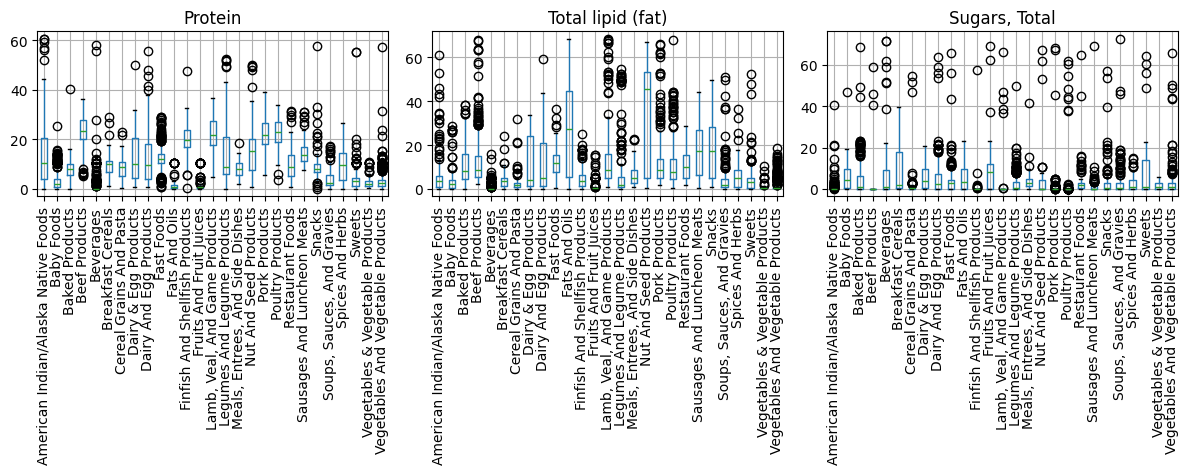

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(12, 5))

for i, col in enumerate(targets):
    corrupted_food_dataset.boxplot(column=col, by='description', ax=axes[i], rot=90)
    axes[i].set_title(col)
    axes[i].set_xlabel('')

plt.suptitle('')
plt.tight_layout()
plt.show()

###Interpretation:
The boxplots show the distribution of each target per food category. The line inside each box is the median  categories where this line is higher contain generally more of that nutrient example for protein animal based categories have high median while vegetables are near 0. The height of the box shows how much foods vary within that category(variance) ,The dots outside the box are extreme foods within that category.since different categories have clearly different distributions This confirms that food category is an important feature

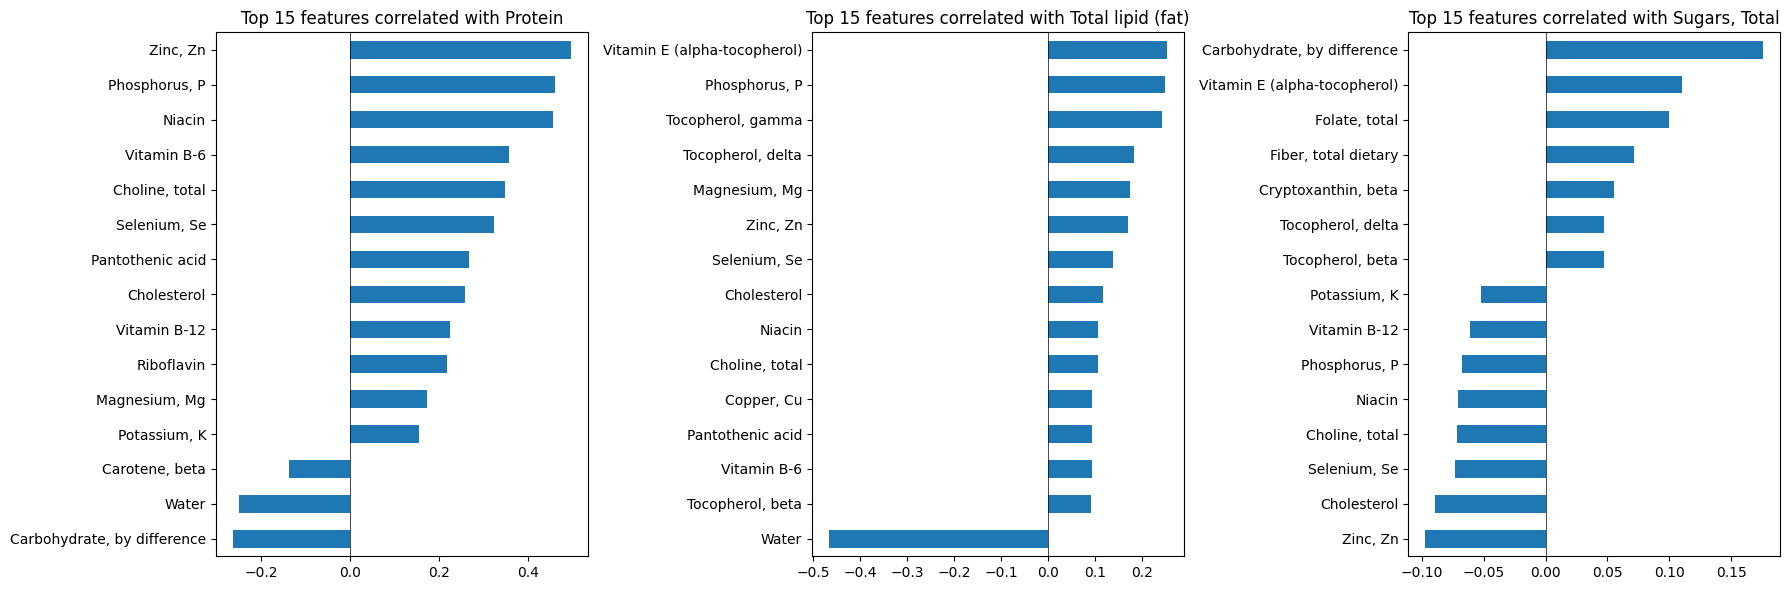

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, target in enumerate(targets):
    corr = corrupted_food_dataset[nutrient_cols].corrwith(corrupted_food_dataset[target])
    top15 = corr.abs().nlargest(15)
    corr[top15.index].sort_values().plot(kind='barh', ax=axes[i])
    axes[i].set_title(f'Top 15 features correlated with {target}')
    axes[i].axvline(x=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

###3.Comparaison between two datasets


In [ ]:
#comparaison between the statistics of the corrupted and original food
targets = ['Protein', 'Total lipid (fat)', 'Sugars, Total']

comparison = pd.DataFrame({
    'Original mean':   original_food_dataset[targets].mean().round(2),
    'Corrupted mean':  corrupted_food_dataset[targets].mean().round(2),
    'Original std':    original_food_dataset[targets].std().round(2),
    'Corrupted std':   corrupted_food_dataset[targets].std().round(2),
    'Original max':    original_food_dataset[targets].max().round(2),
    'Corrupted max':   corrupted_food_dataset[targets].max().round(2),
    'Original count':  original_food_dataset[targets].count(),
    'Corrupted count': corrupted_food_dataset[targets].count(),
})

corrupted_food_dataset
original_food_dataset
print(comparison)

                   Original mean  Corrupted mean  Original std  Corrupted std  \
Protein                    11.93           12.38         10.86          10.09   
Total lipid (fat)          10.69            8.38         16.38          10.78   
Sugars, Total               5.87            2.75         13.37           6.78   

                   Original max  Corrupted max  Original count  \
Protein                   88.32          60.62            7793   
Total lipid (fat)        100.00          68.53            7793   
Sugars, Total             99.80          72.67            7793   

                   Corrupted count  
Protein                       6876  
Total lipid (fat)             6876  
Sugars, Total                 6876  


The comparison shows that the corrupted cleaned data lost rows representing an important part of the data. Statistically we notice a drop in the mean which means the corruption affected high and extreme values, the standard deviation also decreased explaining the compressed distribution meaning the training data no longer fully represents the true nutritional diversity of the original dataset leading to lower R²

In [ ]:
print("Corrupted CLEANED vs CLEAN DATA")
print(f"Clean data shape:        {original_food_dataset.shape}")
print(f"Dirty cleaned shape:     {corrupted_food_dataset.shape}")

Corrupted CLEANED vs CLEAN DATA
Clean data shape:        (7793, 51)
Dirty cleaned shape:     (6876, 51)


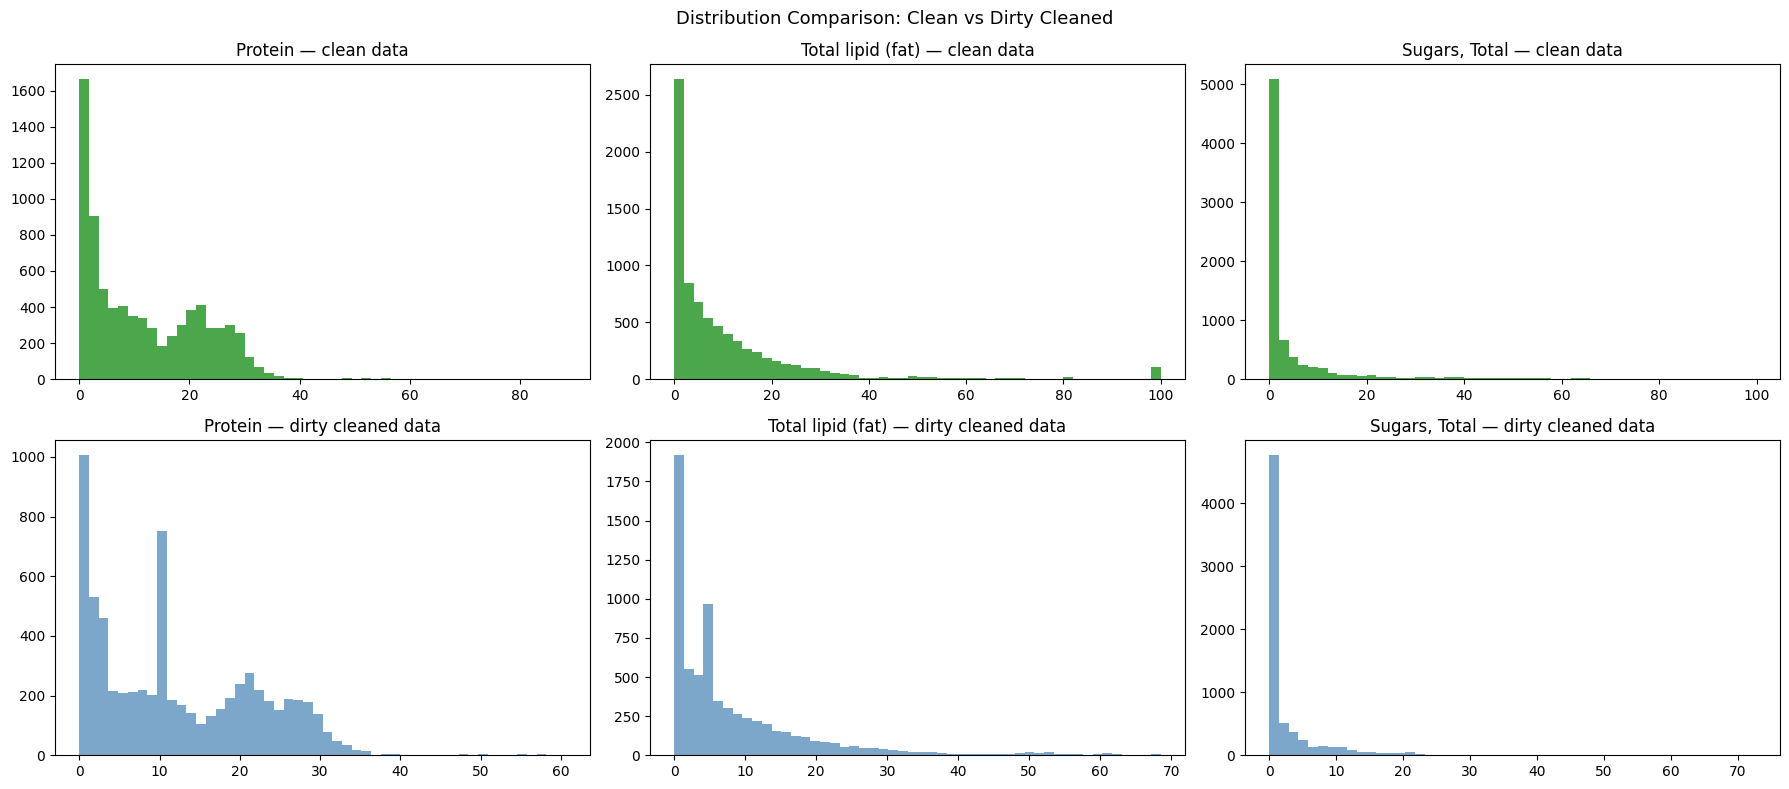

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 8))

for i, col in enumerate(targets):
    axes[0][i].hist(original_food_dataset[col], bins=50, color='green', alpha=0.7)
    axes[0][i].set_title(f'{col} — clean data')

    axes[1][i].hist(corrupted_food_dataset[col], bins=50, color='steelblue', alpha=0.7)
    axes[1][i].set_title(f'{col} — dirty cleaned data')

plt.suptitle('Distribution Comparison: Clean vs Dirty Cleaned', fontsize=13)
plt.tight_layout()
plt.show()

the corrupted cleaned dataset has a similar shape to the clean data for low values but consistently loses the high value range for all three targets.The spikes mean many foods were assigned the exact same values